## Question 1: Text Generation using GRU

In [2]:
!pip install nltk torch matplotlib

import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import nltk
import time
import matplotlib.pyplot as plt

nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('averaged_perceptron_tagger')
nltk.download('averaged_perceptron_tagger_eng')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger.zip.
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger_eng.zip.


True

In [3]:
#load Dataset
text = """The quick brown fox jumps over the lazy dog.
I love natural language processing.
Deep learning models are powerful."""

# Convert to lowercase
text = text.lower()

#Character-Level Preprocessing

chars = sorted(list(set(text)))
char2idx = {ch:i for i,ch in enumerate(chars)}
idx2char = {i:ch for ch,i in char2idx.items()}

encoded = [char2idx[c] for c in text]

seq_length = 10
X = []
Y = []

for i in range(len(encoded) - seq_length):
    X.append(encoded[i:i+seq_length])
    Y.append(encoded[i+seq_length])

X = torch.tensor(X)
Y = torch.tensor(Y)

# GRU Model

In [4]:
class GRUModel(nn.Module):
    def __init__(self, vocab_size, hidden_size):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, hidden_size)
        self.gru = nn.GRU(hidden_size, hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, vocab_size)

    def forward(self, x):
        x = self.embedding(x)
        out, _ = self.gru(x)
        out = self.fc(out[:, -1, :])
        return out

In [5]:
# Train model
model = GRUModel(len(chars), 64)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

for epoch in range(20):
    optimizer.zero_grad()
    output = model(X)
    loss = criterion(output, Y)
    loss.backward()
    optimizer.step()

    print(f"Epoch {epoch}, Loss: {loss.item()}")

Epoch 0, Loss: 3.438941478729248
Epoch 1, Loss: 3.13466215133667
Epoch 2, Loss: 2.863165855407715
Epoch 3, Loss: 2.6064939498901367
Epoch 4, Loss: 2.3791933059692383
Epoch 5, Loss: 2.169308662414551
Epoch 6, Loss: 1.964410662651062
Epoch 7, Loss: 1.7757258415222168
Epoch 8, Loss: 1.6025621891021729
Epoch 9, Loss: 1.4374204874038696
Epoch 10, Loss: 1.2773356437683105
Epoch 11, Loss: 1.123586654663086
Epoch 12, Loss: 0.9785345196723938
Epoch 13, Loss: 0.8450548648834229
Epoch 14, Loss: 0.7260832190513611
Epoch 15, Loss: 0.6214619278907776
Epoch 16, Loss: 0.5302240252494812
Epoch 17, Loss: 0.4510537385940552
Epoch 18, Loss: 0.3816578686237335
Epoch 19, Loss: 0.3209345042705536


In [6]:
# Text Generation
def generate(model, start="the", length=50):
    model.eval()
    input_seq = [char2idx[c] for c in start]

    for _ in range(length):
        inp = torch.tensor([input_seq[-seq_length:]])
        out = model(inp)
        pred = torch.argmax(out).item()
        input_seq.append(pred)

    return ''.join([idx2char[i] for i in input_seq])

print(generate(model))

the lazy dog.
i love lazy dog.
i love lazy dog.
i lov


#Q2: POS Tagging (GRU + LSTM)

In [7]:
sentences = ["I love NLP", "Deep learning is fun"]
tokens = [nltk.word_tokenize(s) for s in sentences]
tags = [nltk.pos_tag(t) for t in tokens]

words = list(set([w for sent in tokens for w in sent]))
pos_tags = list(set([t for sent in tags for _,t in sent]))

word2idx = {w:i for i,w in enumerate(words)}
tag2idx = {t:i for i,t in enumerate(pos_tags)}

In [8]:
# Add padding token to word2idx and tag2idx
padding_word_idx = len(words)
padding_tag_idx = len(pos_tags)
word2idx['<pad>'] = padding_word_idx
tag2idx['<pad>'] = padding_tag_idx

# Find max sequence length
max_seq_len = max(len(s) for s in tokens)

X_padded = []
Y_padded = []

for sent, tag_list in zip(tokens, tags):
    encoded_x = [word2idx[w] for w in sent]
    encoded_y = [tag2idx[t] for _,t in tag_list]

    # Pad sequences
    padded_x = encoded_x + [padding_word_idx] * (max_seq_len - len(encoded_x))
    padded_y = encoded_y + [padding_tag_idx] * (max_seq_len - len(encoded_y))

    X_padded.append(padded_x)
    Y_padded.append(padded_y)

X = torch.tensor(X_padded)
Y = torch.tensor(Y_padded)


# LSTM Model

In [9]:
class LSTMTagger(nn.Module):
    def __init__(self, vocab_size, tagset_size):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, 32)
        self.lstm = nn.LSTM(32, 32, batch_first=True)
        self.fc = nn.Linear(32, tagset_size)

    def forward(self, x):
        x = self.embedding(x)
        out, _ = self.lstm(x)
        return self.fc(out)

In [10]:
model = LSTMTagger(len(word2idx), len(tag2idx))
optimizer = optim.Adam(model.parameters(), lr=0.01)
criterion = nn.CrossEntropyLoss()

for epoch in range(10):
    optimizer.zero_grad()
    out = model(X)
    loss = criterion(out.view(-1, len(tag2idx)), Y.view(-1))
    loss.backward()
    optimizer.step()
    print(loss.item())

1.9466938972473145
1.811612844467163
1.6834341287612915
1.5521029233932495
1.4138699769973755
1.2696332931518555
1.1236904859542847
0.9820372462272644
0.8499593734741211
0.7305911183357239


# Q3: Compare RNN, LSTM, GRU

[nltk_data] Downloading package gutenberg to /root/nltk_data...
[nltk_data]   Unzipping corpora/gutenberg.zip.
/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Training RNN...
Epoch 1/10
286/286 ━━━━━━━━━━━━━━━━━━━━ 21s 60ms/step - accuracy: 0.0306 - loss: 6.5287
Epoch 2/10
286/286 ━━━━━━━━━━━━━━━━━━━━ 18s 51ms/step - accuracy: 0.0468 - loss: 6.1748
Epoch 3/10
286/286 ━━━━━━━━━━━━━━━━━━━━ 14s 50ms/step - accuracy: 0.0704 - loss: 5.8088
Epoch 4/10
286/286 ━━━━━━━━━━━━━━━━━━━━ 14s 49ms/step - accuracy: 0.0952 - loss: 5.5182
Epoch 5/10
286/286 ━━━━━━━━━━━━━━━━━━━━ 15s 52ms/step - accuracy: 0.1137 - loss: 5.2839
Epoch 6/10
286/286 ━━━━━━━━━━━━━━━━━━━━ 15s 51ms/step - accuracy: 0.1269 - loss: 5.0846
Epoch 7/10
286/286 ━━━━━━━━━━━━━━━━━━━━ 18s 63ms/step - accuracy: 0.1388 - loss: 4.9028
Epoch 8/10
286/286 ━━━━━━━━━━━━━━━━━━━━ 15s 52ms/step - accuracy: 0.1500 - loss: 4.7333
Epoch 9/10
286/286 ━━━━━━━━━━━━━━━━━━━━ 15s 51ms/step - accuracy: 0.1582 - loss: 4.5819
Epoch 10/10
286/286 ━━━━━━━━━━━━━━━━━━━━ 22s 56ms/step - accuracy: 0.1697 - loss: 4.4298
Training LSTM...
Epoch 1/10
286/286 ━━━━━━━━━━━━━━━━━━━━ 29s 92ms/step - accuracy: 0.0330 - loss: 6.495

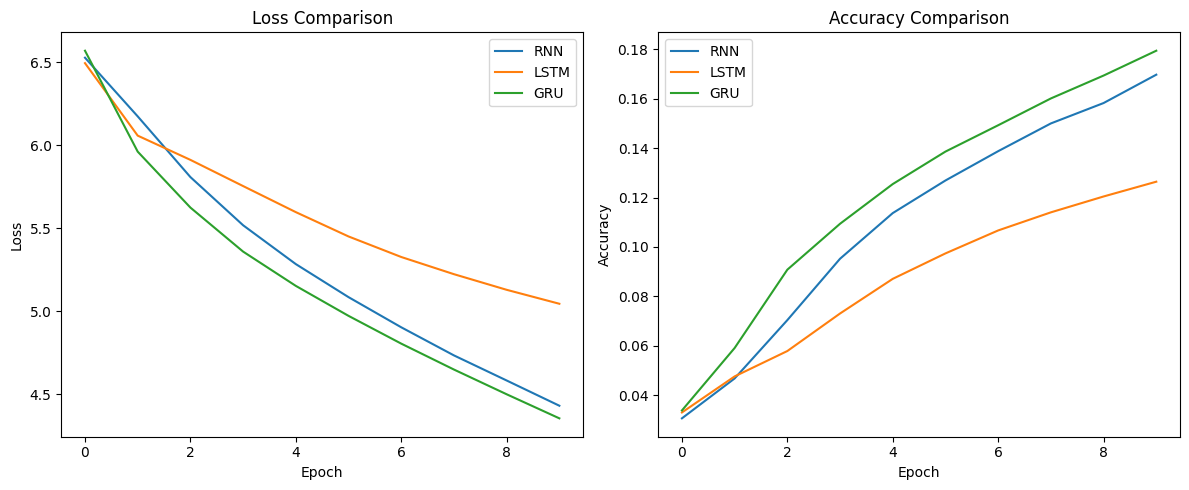


RNN Output:
she was not to be a little deal of the young man

LSTM Output:
she was not a very man and the very man and the

GRU Output:
she was very much pleased and the children of the same and


In [11]:
import numpy as np
import tensorflow as tf
import nltk
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.layers import SimpleRNN, LSTM, GRU
import matplotlib.pyplot as plt

# -------------------------------
# Load dataset
# -------------------------------
nltk.download('gutenberg')
text = nltk.corpus.gutenberg.raw('austen-emma.txt').lower()

# 🔥 LIMIT DATA (IMPORTANT)
text = text[:200000]

# -------------------------------
# Tokenization
# -------------------------------
vocab_size = 5000
tokenizer = Tokenizer(num_words=vocab_size, oov_token="<OOV>")
tokenizer.fit_on_texts([text])

total_words = vocab_size   # 🔥 FIX HERE

sequences = tokenizer.texts_to_sequences([text])[0]

# -------------------------------
# Create sequences
# -------------------------------
seq_len = 20
input_sequences = []

for i in range(seq_len, len(sequences)):
    input_sequences.append(sequences[i-seq_len:i+1])

input_sequences = np.array(input_sequences)

X = input_sequences[:, :-1]
y = input_sequences[:, -1]

y = tf.keras.utils.to_categorical(y, num_classes=total_words)

# -------------------------------
# Model builder
# -------------------------------
def build_model(cell_type):
    model = tf.keras.Sequential([
        tf.keras.layers.Embedding(total_words, 64, input_length=seq_len),
        cell_type(128),
        tf.keras.layers.Dense(total_words, activation='softmax')
    ])
    model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
    return model

# -------------------------------
# Build models
# -------------------------------
rnn_model = build_model(SimpleRNN)
lstm_model = build_model(LSTM)
gru_model = build_model(GRU)

# -------------------------------
# Train models
# -------------------------------
print("Training RNN...")
rnn_hist = rnn_model.fit(X, y, epochs=10, batch_size=128, verbose=1)

print("Training LSTM...")
lstm_hist = lstm_model.fit(X, y, epochs=10, batch_size=128, verbose=1)

print("Training GRU...")
gru_hist = gru_model.fit(X, y, epochs=10, batch_size=128, verbose=1)

# -------------------------------
# Plot loss
# -------------------------------
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(rnn_hist.history['loss'], label='RNN')
plt.plot(lstm_hist.history['loss'], label='LSTM')
plt.plot(gru_hist.history['loss'], label='GRU')
plt.legend()
plt.title("Loss Comparison")
plt.xlabel("Epoch")
plt.ylabel("Loss")

# -------------------------------
# Plot accuracy
# -------------------------------
plt.subplot(1, 2, 2)
plt.plot(rnn_hist.history['accuracy'], label='RNN')
plt.plot(lstm_hist.history['accuracy'], label='LSTM')
plt.plot(gru_hist.history['accuracy'], label='GRU')
plt.legend()
plt.title("Accuracy Comparison")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.tight_layout()
plt.show()

# -------------------------------
# Text generation function
# -------------------------------
index_word = {v: k for k, v in tokenizer.word_index.items()}

def generate_text(model, seed_text, next_words=10):
    for _ in range(next_words):
        token_list = tokenizer.texts_to_sequences([seed_text])[0]
        token_list = token_list[-seq_len:]
        token_list = pad_sequences([token_list], maxlen=seq_len, padding='pre')

        preds = model.predict(token_list, verbose=0)[0]
        predicted = np.argmax(preds)

        word = index_word.get(predicted, "")
        seed_text += " " + word

    return seed_text

# -------------------------------
# Generate samples
# -------------------------------
print("\nRNN Output:")
print(generate_text(rnn_model, "she was"))

print("\nLSTM Output:")
print(generate_text(lstm_model, "she was"))

print("\nGRU Output:")
print(generate_text(gru_model, "she was"))